In [1]:
# Cell 1 - Check GPU and install packages
import torch
print(f"GPU available: {torch.cuda.is_available()}")
print(f"GPU name: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")

!pip install librosa soundfile omegaconf seaborn -q
print("✓ Packages installed")

GPU available: True
GPU name: Tesla T4
✓ Packages installed


In [2]:
# Cell 2 - Download LibriSpeech dev-clean and test-clean
import os
os.makedirs("data/raw/librispeech", exist_ok=True)

print("Downloading dev-clean (~337MB)...")
!wget -q --show-progress "https://www.openslr.org/resources/12/dev-clean.tar.gz" -O "data/raw/librispeech/dev-clean.tar.gz"

print("Downloading test-clean (~346MB)...")
!wget -q --show-progress "https://www.openslr.org/resources/12/test-clean.tar.gz" -O "data/raw/librispeech/test-clean.tar.gz"

print("Extracting...")
!tar -xzf "data/raw/librispeech/dev-clean.tar.gz" -C "data/raw/librispeech/"
!tar -xzf "data/raw/librispeech/test-clean.tar.gz" -C "data/raw/librispeech/"

# Verify
flac_files = []
for root, dirs, files in os.walk("data/raw/librispeech"):
    for f in files:
        if f.endswith(".flac"):
            flac_files.append(os.path.join(root, f))

print(f"\n✓ LibriSpeech files found: {len(flac_files)}")
print(f"Example: {flac_files[0]}")

data/raw/librispeec 100%[===================>] 322.27M  9.81MB/s    in 33s     
data/raw/librispeec 100%[===================>] 330.60M  21.5MB/s    in 17s     
Extracting...

✓ LibriSpeech files found: 5323
Example: data/raw/librispeech/LibriSpeech/test-clean/4077/13751/4077-13751-0015.flac


In [4]:
# Cell 4 - Download NOIZEUS from GitHub mirror
import os
os.makedirs("data/raw/noizeus", exist_ok=True)

!git clone https://github.com/chmodsss/noizeus_corpora.git data/raw/noizeus/noizeus_corpora

# Count wav files
wav_files = []
for root, dirs, files in os.walk("data/raw/noizeus"):
    for f in files:
        if f.endswith(".wav"):
            wav_files.append(os.path.join(root, f))

print(f"✓ NOIZEUS wav files found: {len(wav_files)}")
if wav_files:
    print(f"Example: {wav_files[0]}")

Cloning into 'data/raw/noizeus/noizeus_corpora'...
remote: Enumerating objects: 1204, done.
remote: Total 1204 (delta 0), reused 0 (delta 0), pack-reused 1204 (from 1)
Receiving objects: 100% (1204/1204), 35.12 MiB | 37.00 MiB/s, done.
Resolving deltas: 100% (34/34), done.
✓ NOIZEUS wav files found: 990
Example: data/raw/noizeus/noizeus_corpora/NOIZEUS/car_10dB/wav/sp13_car_sn10.wav


In [5]:
# Cell 5 - Generate reverberant domain from real LibriSpeech test-clean
import numpy as np
import soundfile as sf
import os

os.makedirs("data/raw/reverberant", exist_ok=True)

# Collect test-clean files (different speakers from dev-clean)
test_clean_files = []
for root, dirs, files in os.walk("data/raw/librispeech/LibriSpeech/test-clean"):
    for f in files:
        if f.endswith(".flac"):
            test_clean_files.append(os.path.join(root, f))

print(f"test-clean files available: {len(test_clean_files)}")

count = 0
for i, path in enumerate(test_clean_files[:500]):
    y, sr = sf.read(path)
    if y.ndim > 1:
        y = y.mean(axis=1)
    y = y.astype(np.float32)

    # Synthetic RIR with random room size (T60 = 0.3s to 1.2s)
    t60    = np.random.uniform(0.3, 1.2)
    length = int(sr * t60)
    rir    = np.random.randn(length)
    decay  = np.linspace(0, -60, length)
    rir    = rir * (10 ** (decay / 20))
    rir    = rir / (np.abs(rir).max() + 1e-9)

    # Convolve via FFT
    n       = len(y) + len(rir) - 1
    y_reverb = np.fft.irfft(
        np.fft.rfft(y, n=n) * np.fft.rfft(rir, n=n), n=n
    )[:len(y)].astype(np.float32)

    # Normalise to original RMS
    rms_in  = np.sqrt(np.mean(y ** 2))
    rms_out = np.sqrt(np.mean(y_reverb ** 2))
    y_reverb = y_reverb * (rms_in / (rms_out + 1e-9))

    sf.write(f"data/raw/reverberant/reverb_{i:04d}.wav", y_reverb, sr)
    count += 1

    if i % 100 == 0:
        print(f"  {i}/500 done")

print(f"\n✓ Generated {count} reverberant files")

test-clean files available: 2620
  0/500 done
  100/500 done
  200/500 done
  300/500 done
  400/500 done

✓ Generated 500 reverberant files


In [6]:
# Cell 6 - Generate accented and conversational domains using espeak-ng
import subprocess
import numpy as np
import os

!apt-get install -y espeak-ng -q

os.makedirs("data/raw/accented", exist_ok=True)
os.makedirs("data/raw/conversational", exist_ok=True)

# ── Accented ──────────────────────────────────────────────────
sentences = [
    "The weather today is quite pleasant and warm",
    "I would like to order some food please",
    "Can you tell me how to get to the station",
    "The meeting is scheduled for tomorrow morning",
    "Please speak slowly so I can understand you",
    "I have been living here for three years now",
    "The price of this item is very expensive",
    "Could you please repeat that one more time",
    "I am looking for the nearest hospital",
    "The train arrives at half past seven",
    "She studies mathematics at the university",
    "We need to finish this project by Friday",
    "The children are playing in the garden",
    "I will call you back in a few minutes",
    "The restaurant opens at six in the evening",
    "He forgot to bring his identification card",
    "The flight was delayed by two hours",
    "I need to exchange some foreign currency",
    "The museum is closed on Monday mornings",
    "Please fill out this form completely",
    "The hospital is located on the main street downtown",
    "I need to book an appointment with the doctor tomorrow",
    "The supermarket closes at ten o clock in the evening",
    "Could you please help me find the right platform",
    "I would like to make a reservation for two people",
    "The temperature outside is dropping very quickly today",
    "My passport expires at the end of next month",
    "The bus stop is just around the corner from here",
    "I am looking for a job in the technology sector",
    "The library opens at nine in the morning on weekdays",
    "The quick brown fox jumps over the lazy dog",
    "She sells seashells by the seashore every morning",
    "All that glitters is not gold according to the saying",
    "A penny saved is a penny earned my grandfather said",
    "Actions speak louder than words in every situation",
    "Better late than never but never late is better",
    "Every cloud has a silver lining if you look carefully",
    "Fortune favors the bold and the brave always",
    "Good things come to those who wait patiently",
    "Hard work and dedication always pay off in the end",
    "Knowledge is power and power is knowledge combined",
    "Laughter is the best medicine for any situation",
    "Nothing ventured nothing gained in life and business",
    "Opportunity knocks only once so be ready always",
    "Practice makes perfect if you do it consistently",
    "Quality over quantity should always be the priority",
    "Rome was not built in a single day remember",
    "Slow and steady wins the race every single time",
    "The early bird always catches the worm in morning",
    "United we stand divided we fall as a nation",
]

accents = ["en-us", "en-gb", "en-029", "en-gb-scotland", "en-gb-x-rp"]
count = 0
for accent in accents:
    for i, sentence in enumerate(sentences):
        out_path = f"data/raw/accented/accented_{accent.replace('-','_')}_{i:03d}.wav"
        cmd = f'espeak-ng -v {accent} -s 140 -p 50 "{sentence}" -w {out_path}'
        result = subprocess.run(cmd, shell=True, capture_output=True)
        if result.returncode == 0:
            count += 1

print(f"✓ Generated {count} accented files")

# ── Conversational ────────────────────────────────────────────
conv_sentences = [
    "so like I was just sitting there and then suddenly everything changed",
    "yeah no I mean I get what youre saying but also kind of not really",
    "okay so anyway the point is that we need to figure this out together",
    "I was literally just about to say the exact same thing honestly",
    "so basically what ended up happening was totally unexpected by everyone",
    "I dont know its just one of those things you know what I mean",
    "wait so are you saying that the whole plan is off now or what",
    "honestly I think the best thing to do right now is just wait and see",
    "so then I told him look this is not working out the way we planned",
    "I mean at this point I just want to get it done and move on",
    "yeah so I figured if I just kept going it would eventually work out",
    "no but seriously though have you actually thought about what happens next",
    "so the thing is right I had this whole idea but then it just fell apart",
    "I cant even begin to explain how frustrating the whole situation was",
    "okay but hear me out for a second because I think I have a solution",
    "so yeah long story short we just decided to start over from scratch",
    "I mean look its not ideal but what else are we supposed to do here",
    "honestly the more I think about it the more confused I get about it",
    "so I was talking to her and she was like I have no idea what happened",
    "yeah and then the whole thing just kind of spiraled out of control fast",
    "wait no thats not what I meant let me try to explain it differently",
    "so basically I spent the whole day trying to fix this one tiny problem",
    "I just feel like nobody actually listens to what I am trying to say",
    "okay so moving on from that lets talk about what we are doing tomorrow",
    "honestly between you and me I think they made the wrong decision there",
    "so like obviously I was upset about it but I tried not to show it",
    "I mean the whole situation is just really weird if you think about it",
    "yeah no totally I completely understand where you are coming from now",
    "so anyway I ended up just calling it a day and going home early",
    "I just think that at the end of the day we all want the same thing",
    "so I was thinking about it and I think we should just go for it",
    "honestly I have no idea what is going on anymore with this whole thing",
    "yeah so basically I told them exactly what I thought and they agreed",
    "I mean look at the end of the day it is what it is right",
    "so then she called me and was like you are not going to believe this",
    "okay I am just going to say it because nobody else seems to want to",
    "I dont know man sometimes things just dont work out the way you planned",
    "so like obviously I was not expecting that to happen at all yesterday",
    "wait a second let me just think about this before I say anything",
    "yeah no I totally get it I have been in that exact same situation before",
    "so anyway I figured the best thing to do was just be honest about it",
    "I mean it is kind of a long story but I will try to keep it short",
    "honestly the whole thing just came out of nowhere and surprised everyone",
    "so I ended up having to redo the entire thing from scratch again",
    "yeah and then he just looked at me like I had said something crazy",
    "I just think that sometimes you have to take a step back you know",
    "so like what ended up happening was actually kind of funny in hindsight",
    "okay so the thing is I had already made up my mind before they asked",
    "I mean I tried to explain it but they just did not seem to understand",
    "yeah so long story short everything worked out fine in the end thankfully",
]

count2 = 0
for i, sentence in enumerate(conv_sentences):
    speed = np.random.randint(160, 200)
    pitch = np.random.randint(40, 70)
    out_path = f"data/raw/conversational/conv_{i:03d}.wav"
    cmd = f'espeak-ng -v en-us -s {speed} -p {pitch} "{sentence}" -w {out_path}'
    result = subprocess.run(cmd, shell=True, capture_output=True)
    if result.returncode == 0:
        count2 += 1

print(f"✓ Generated {count2} conversational files")

Reading package lists...
Building dependency tree...
Reading state information...
The following additional packages will be installed:
  espeak-ng-data libespeak-ng1 libpcaudio0 libsonic0
The following NEW packages will be installed:
  espeak-ng espeak-ng-data libespeak-ng1 libpcaudio0 libsonic0
0 upgraded, 5 newly installed, 0 to remove and 37 not upgraded.
Need to get 4,526 kB of archives.
After this operation, 11.9 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 libpcaudio0 amd64 1.1-6build2 [8,956 B]
Get:2 http://archive.ubuntu.com/ubuntu jammy/main amd64 libsonic0 amd64 0.2.0-11build1 [10.3 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 espeak-ng-data amd64 1.50+dfsg-10ubuntu0.1 [3,956 kB]
Get:4 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 libespeak-ng1 amd64 1.50+dfsg-10ubuntu0.1 [207 kB]
Get:5 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 espeak-ng amd64 1.50+dfsg-10ubuntu0.1 [343

In [7]:
# Cell 7 - Top up accented and conversational to 500 each
import subprocess
import numpy as np
import os

more_sentences = [
    "The company has been in business for over twenty years",
    "I would like to open a new bank account please",
    "The concert starts at eight and ends around midnight",
    "He speaks three languages fluently including Mandarin",
    "The new policy will come into effect next Monday morning",
    "I forgot my umbrella and now it is raining heavily",
    "The children finished their homework before dinner time",
    "We are planning a trip to the mountains next weekend",
    "The report needs to be submitted by end of day Friday",
    "I have been waiting for this moment for a very long time",
    "The electricity bill this month is higher than usual",
    "She always arrives early to make sure everything is ready",
    "The project deadline has been moved to next Wednesday",
    "I would appreciate it if you could respond by tomorrow",
    "The new software update fixed all the previous issues",
    "He drives to work every day to avoid the crowded trains",
    "The garden looks beautiful in the spring and summer months",
    "I need to renew my driving license before it expires",
    "The weather forecast says it will snow tomorrow morning",
    "She has been working on this painting for several weeks",
    "The meeting was postponed due to unforeseen circumstances",
    "I always drink a cup of coffee before starting my work",
    "The neighbors are very friendly and helpful to everyone",
    "He recently moved to a new apartment closer to the office",
    "The scholarship covers all tuition fees and living expenses",
    "Please make sure you have your ticket ready to show",
    "The conference will be held in the main hall upstairs",
    "I need directions to the nearest petrol station please",
    "The package was delivered to the wrong address again",
    "She graduated from university with honors last summer",
    "I cannot believe how quickly the time has gone by",
    "The traffic on the motorway was very heavy this morning",
    "She asked me to pass the salt and pepper please",
    "The doctor said I need to rest for a few days",
    "I am going to the market to buy some fresh vegetables",
    "The stadium was completely full for the final match",
    "He told me the news and I was absolutely shocked",
    "I have never seen anything quite like this before",
    "The building on the corner has just been renovated",
    "She plays the piano beautifully and has done since childhood",
    "I think we should leave early to avoid the traffic",
    "The exam results will be announced at the end of the week",
    "He has been feeling much better since he started the medication",
    "I would like to speak to the manager if possible please",
    "The sunrise this morning was absolutely breathtaking and beautiful",
    "She told me she had been waiting for over an hour",
    "The new bridge will cut the journey time significantly",
    "I need to call my family to let them know I arrived",
    "The tickets for the show sold out within minutes online",
    "He finished reading the book in just two days",
]

accents = ["en-us", "en-gb", "en-029", "en-gb-scotland", "en-gb-x-rp"]
existing = len([f for f in os.listdir("data/raw/accented") if f.endswith(".wav")])
print(f"Current accented: {existing}")

count = 0
for accent in accents:
    for i, sentence in enumerate(more_sentences):
        if existing + count >= 500:
            break
        out_path = f"data/raw/accented/accented2_{accent.replace('-','_')}_{i:03d}.wav"
        cmd = f'espeak-ng -v {accent} -s 140 -p 50 "{sentence}" -w {out_path}'
        result = subprocess.run(cmd, shell=True, capture_output=True)
        if result.returncode == 0:
            count += 1
    if existing + count >= 500:
        break

print(f"✓ Accented total: {existing + count}")

# ── Top up conversational ─────────────────────────────────────
more_conv = [
    "so I was just telling her about what happened and she could not believe it",
    "honestly at this point I have just stopped trying to understand the whole thing",
    "yeah so we ended up staying there way longer than we originally planned to",
    "I mean the problem is that nobody actually told us about the change beforehand",
    "so like I get what you are saying but I just see it differently you know",
    "okay so basically what happened was I forgot to save the file and lost everything",
    "I dont even know where to start with explaining how that whole day went",
    "yeah and then out of nowhere she just decided to cancel the whole thing",
    "so I figured I would just go ahead and do it without asking anyone first",
    "honestly I think the whole situation could have been avoided if we just communicated",
    "so then he comes in and acts like nothing happened which was just so weird",
    "I mean look I am not saying it was perfect but it was pretty good overall",
    "yeah no I totally see your point and I think you are probably right about it",
    "so basically we had this whole plan and then it all fell apart at the last minute",
    "I just feel like every time we get close to finishing something else comes up",
    "okay but here is the thing right nobody actually read the instructions properly",
    "so I was on my way there and I just had this feeling something was off",
    "yeah and I was like wait a minute that is not what we agreed on at all",
    "honestly I spent so long working on it and then they just changed the brief",
    "so anyway we figured we would just make the best of the situation we were in",
    "I mean it is not the end of the world but it is still pretty frustrating",
    "yeah so she called me this morning and told me the whole story from the start",
    "so like I knew it was going to be complicated but not this complicated honestly",
    "okay I think the main issue here is that we are all on different pages right now",
    "I dont know maybe I am overthinking it but something just does not feel right",
    "so then we all just looked at each other and nobody knew what to say next",
    "yeah honestly it was one of those situations where you just have to laugh about it",
    "so basically I had to redo the whole thing from scratch which took forever",
    "I mean at the end of the day we got it done and that is what matters most",
    "yeah so long story short it turned out fine but it was stressful for a while",
    "so like the whole point was to keep it simple but somehow it got really complicated",
    "I just think we need to be more organised next time so this does not happen again",
    "okay so moving forward I think the best approach is to just take it one step at a time",
    "yeah no I get it I have been in that exact position before and it is not easy",
    "honestly I think the thing that surprised me most was how quickly it all happened",
    "so I ended up just calling them directly to sort it out rather than emailing",
    "I mean the whole experience was a bit overwhelming but also kind of exciting",
    "yeah and then just when we thought it was all sorted another problem came up",
    "so basically I just had to trust the process and hope it would all work out fine",
    "I dont know it just felt like one of those days where nothing was going right",
    "so like we had been planning this for weeks and then it all changed overnight",
    "okay honestly looking back on it now it was probably the right decision to make",
    "yeah so I spoke to them about it and they were actually really understanding",
    "I mean I was nervous about bringing it up but I am really glad that I did",
    "so then everything kind of fell into place and it actually worked out really well",
    "honestly I just want to get to a point where we are not constantly putting out fires",
    "so yeah I think the lesson here is to always have a backup plan just in case",
    "I mean you just never know what is going to happen so you have to be prepared",
    "yeah no totally that is exactly what I was thinking when I first heard about it",
    "so anyway that is basically the whole story and now you know as much as I do",
]

existing2 = len([f for f in os.listdir("data/raw/conversational") if f.endswith(".wav")])
print(f"\nCurrent conversational: {existing2}")

count2 = 0
for i, sentence in enumerate(more_conv):
    if existing2 + count2 >= 500:
        break
    speed = np.random.randint(160, 200)
    pitch = np.random.randint(40, 70)
    out_path = f"data/raw/conversational/conv2_{i:03d}.wav"
    cmd = f'espeak-ng -v en-us -s {speed} -p {pitch} "{sentence}" -w {out_path}'
    result = subprocess.run(cmd, shell=True, capture_output=True)
    if result.returncode == 0:
        count2 += 1

print(f"✓ Conversational total: {existing2 + count2}")

Current accented: 250
✓ Accented total: 500

Current conversational: 50
✓ Conversational total: 100


In [8]:
# Cell 8 - Top up conversational to 500
import subprocess
import numpy as np
import os

# Large pool of conversational sentences
sentences_pool = [
    "so I was just thinking about everything that happened and it still does not make sense",
    "yeah no honestly I think we just need to accept that it is what it is at this point",
    "okay so the thing is right I tried to explain it three times and they still did not get it",
    "I mean look I am not trying to be difficult I just think there is a better way to do this",
    "so then she turns around and says she had no idea what was going on which was just bizarre",
    "honestly I have been thinking about it all day and I still do not know what the right call is",
    "yeah so basically the whole thing unravelled pretty quickly once people started asking questions",
    "I dont know man I feel like every time we make progress something comes along and sets us back",
    "so like obviously I wanted to say something in the moment but I just froze and said nothing",
    "okay but hear me out right what if we just scrap the whole thing and start fresh from scratch",
    "I mean at a certain point you just have to cut your losses and move on to something else",
    "yeah and the weird thing is nobody seemed particularly surprised when it all fell through",
    "so I ended up just sending a message instead of calling because I did not want the awkwardness",
    "honestly the whole meeting could have been an email and everyone in the room knew it too",
    "so like I get that it is complicated but at the same time it really does not have to be",
    "I just think that if we had communicated better from the start none of this would have happened",
    "yeah no I totally hear you and I think you make a really valid point about the whole thing",
    "so basically what I am trying to say is that we need to reconsider our approach going forward",
    "I mean the feedback was actually pretty useful even if it was not easy to hear at the time",
    "so then out of nowhere he just brings up something that happened like three months ago",
    "honestly I was so close to just walking out but I figured I should hear them out first",
    "yeah so we stayed up until like two in the morning trying to figure out what went wrong",
    "so like the original plan was completely different but then everything just kind of evolved",
    "I dont even know how to describe it it was just one of those really strange situations",
    "okay so I know this sounds weird but I actually think it might have worked out for the best",
    "yeah and then everyone started talking at once and it just became completely chaotic",
    "so I just sat there nodding along even though I had absolutely no idea what was going on",
    "honestly I think the biggest mistake we made was not asking enough questions at the beginning",
    "so like we all assumed we were on the same page but it turned out we really were not",
    "I mean I wish someone had told me earlier because it would have saved a lot of time",
    "yeah so the situation is basically under control now but it was touch and go for a while",
    "so anyway I decided to just be upfront about it rather than dancing around the subject",
    "honestly it is one of those things that seems really obvious in hindsight but not at the time",
    "so I called him back and he was actually really calm about the whole thing which surprised me",
    "I just think we all need to take a breath and look at the bigger picture here for a second",
    "yeah no I get why you are frustrated I would be feeling exactly the same way in your position",
    "so basically we had three options and none of them were particularly good if I am being honest",
    "I mean the fact that it worked at all is kind of a miracle given everything that was going on",
    "so then the whole group dynamic just shifted completely and it has been different ever since",
    "honestly I do not think anyone could have predicted that outcome given the information we had",
    "so like I went in expecting one thing and came out with a completely different perspective",
    "yeah and what was funny is that the solution ended up being really simple once we found it",
    "I mean sometimes you are just too close to the problem to see what is right in front of you",
    "so I think the takeaway from all of this is that we need to be more flexible going forward",
    "honestly I just want to get back to a point where things are running smoothly again",
    "so like the whole experience was stressful but I think we all learned something valuable from it",
    "yeah no I completely agree and I think that is exactly the direction we should be heading in",
    "I mean we have come too far to give up now so I think we just push through and finish it",
    "so anyway that is where things stand right now and I guess we just wait and see what happens",
    "honestly at the end of the day I think we did the best we could with what we had available",
    "so I was just about to give up on the whole thing when suddenly it all just clicked into place",
    "yeah and I think the reason it works is because everyone involved actually cares about the outcome",
    "I mean look it has not been easy but I think we are in a much better position than we were",
    "so like going into it I had zero expectations and then it ended up being genuinely really good",
    "honestly the hardest part was just getting started because once we did everything flowed naturally",
    "so then I realised that the thing I was most worried about was not actually a problem at all",
    "yeah no and I think that is the key insight right there that changes how you look at everything",
    "I mean once you reframe it that way it suddenly becomes a lot less overwhelming and more manageable",
    "so basically all I am saying is that we should trust the process and not panic when things get hard",
    "honestly I think the people who do best in these situations are the ones who stay calm under pressure",
    "so like I know it feels like a lot right now but I genuinely think we are going to get through this",
    "yeah and once it is all done we will probably look back and realise it was not as bad as it seemed",
    "I mean that is usually how it goes right you stress about something and then it just works itself out",
    "so anyway I have said my piece and now I guess the ball is in their court and we just have to wait",
    "honestly I feel a lot better having talked about it because I have been holding that in for a while",
    "so like whatever happens next I just want everyone to know that I think we gave it our best shot",
    "yeah no totally and I think that counts for a lot even if the outcome was not what we hoped for",
    "I mean at the very least we know what not to do next time which is actually really valuable",
    "so basically I am cautiously optimistic about where things are heading and I think you should be too",
    "honestly just take it one day at a time and do not try to solve everything all at once you know",
]

existing = len([f for f in os.listdir("data/raw/conversational") if f.endswith(".wav")])
print(f"Current conversational: {existing}")

count = 0
idx = 0
while existing + count < 500:
    sentence = sentences_pool[idx % len(sentences_pool)]
    speed = np.random.randint(160, 200)
    pitch = np.random.randint(40, 70)
    out_path = f"data/raw/conversational/conv3_{idx:04d}.wav"
    cmd = f'espeak-ng -v en-us -s {speed} -p {pitch} "{sentence}" -w {out_path}'
    result = subprocess.run(cmd, shell=True, capture_output=True)
    if result.returncode == 0:
        count += 1
    idx += 1

print(f"✓ Conversational total: {existing + count}")

Current conversational: 100
✓ Conversational total: 500


In [9]:
# Cell 9 - Build final manifest
import pandas as pd
import soundfile as sf
import os
import random

random.seed(42)
records = []

domain_sources = {
    "clean":          ("data/raw/librispeech/LibriSpeech/dev-clean", ".flac"),
    "noisy":          ("data/raw/noizeus/noizeus_corpora/NOIZEUS",   ".wav"),
    "reverberant":    ("data/raw/reverberant",                        ".wav"),
    "accented":       ("data/raw/accented",                           ".wav"),
    "conversational": ("data/raw/conversational",                     ".wav"),
}

for domain, (folder, ext) in domain_sources.items():
    for root, dirs, files in os.walk(folder):
        for f in files:
            if f.endswith(ext):
                path = os.path.join(root, f)
                try:
                    info = sf.info(path)
                    dur = info.frames / info.samplerate
                    if dur >= 0.5:
                        records.append({
                            "audio_path": path,
                            "domain":     domain,
                            "duration":   dur
                        })
                except:
                    pass

df = pd.DataFrame(records)

print("Raw domain counts:")
print(df["domain"].value_counts())

# Cap each domain at 500
balanced = []
for domain in ["clean", "noisy", "reverberant", "accented", "conversational"]:
    domain_df = df[df["domain"] == domain].sample(
        n=min(500, len(df[df["domain"] == domain])),
        random_state=42
    )
    balanced.append(domain_df)

df = pd.concat(balanced).reset_index(drop=True)

# Assign splits
df["split"] = "train"
indices = df.index.tolist()
random.shuffle(indices)
n_val  = int(len(indices) * 0.10)
n_test = int(len(indices) * 0.10)
df.loc[indices[:n_val],             "split"] = "val"
df.loc[indices[n_val:n_val+n_test], "split"] = "test"

os.makedirs("data/processed", exist_ok=True)
df.to_csv("data/processed/manifest.csv", index=False)

print("\nFinal domain counts:")
print(df["domain"].value_counts())
print(f"\nSplit counts:")
print(df["split"].value_counts())
print(f"\nTotal: {len(df)} samples")
print("✓ Manifest saved")

Raw domain counts:
domain
clean             2703
noisy              990
reverberant        500
accented           500
conversational     500
Name: count, dtype: int64

Final domain counts:
domain
clean             500
noisy             500
reverberant       500
accented          500
conversational    500
Name: count, dtype: int64

Split counts:
split
train    2000
val       250
test      250
Name: count, dtype: int64

Total: 2500 samples
✓ Manifest saved


In [10]:
# Cell 10 - Load model and datasets
import os, random, time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import Wav2Vec2Model, Wav2Vec2Processor
import torchaudio
import soundfile as sf
from sklearn.metrics import accuracy_score, f1_score, classification_report

# ── Config ────────────────────────────────────────────────────
DOMAIN_LABELS = {"clean": 0, "noisy": 1, "reverberant": 2, "accented": 3, "conversational": 4}
ID_TO_DOMAIN  = {v: k for k, v in DOMAIN_LABELS.items()}
NUM_CLASSES   = 5
SR            = 16000
MAX_DURATION  = 8.0
BATCH_SIZE    = 8
EPOCHS        = 15
LR            = 3e-5
DEVICE        = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

# ── Dataset ───────────────────────────────────────────────────
class DomainDataset(Dataset):
    def __init__(self, manifest_path, processor, split="train"):
        df = pd.read_csv(manifest_path)
        self.df        = df[df["split"] == split].reset_index(drop=True)
        self.processor = processor
        self.max_samples = int(MAX_DURATION * SR)
        self.split     = split
        print(f"[{split}] {len(self.df)} samples")

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        try:
            y, sr = sf.read(row["audio_path"])
            if y.ndim > 1:
                y = y.mean(axis=1)
            y = y.astype(np.float32)

            # Resample if needed
            if sr != SR:
                y_tensor = torch.from_numpy(y).unsqueeze(0)
                y_tensor = torchaudio.functional.resample(y_tensor, sr, SR)
                y = y_tensor.squeeze(0).numpy()

            # Trim or pad
            if len(y) > self.max_samples:
                if self.split == "train":
                    start = random.randint(0, len(y) - self.max_samples)
                else:
                    start = (len(y) - self.max_samples) // 2
                y = y[start:start + self.max_samples]

            # Normalise
            rms = np.sqrt(np.mean(y ** 2))
            if rms > 0:
                y = y / (rms + 1e-9) * 0.1

        except Exception as e:
            y = np.zeros(SR, dtype=np.float32)

        inputs = self.processor(
            y, sampling_rate=SR, return_tensors="pt", padding=False
        )
        return {
            "input_values": inputs.input_values.squeeze(0),
            "label": torch.tensor(DOMAIN_LABELS[row["domain"]], dtype=torch.long)
        }

def collate_fn(batch):
    input_values = [b["input_values"] for b in batch]
    labels       = torch.stack([b["label"] for b in batch])
    max_len      = max(x.shape[0] for x in input_values)
    padded       = torch.zeros(len(input_values), max_len)
    for i, x in enumerate(input_values):
        padded[i, :x.shape[0]] = x
    return {"input_values": padded, "labels": labels}

# ── Model ─────────────────────────────────────────────────────
class DomainClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = Wav2Vec2Model.from_pretrained(
            "facebook/wav2vec2-base",
            output_hidden_states=True
        )
        # Freeze CNN + bottom 8 transformer layers
        for param in self.backbone.feature_extractor.parameters():
            param.requires_grad = False
        for param in self.backbone.feature_projection.parameters():
            param.requires_grad = False
        for i, layer in enumerate(self.backbone.encoder.layers):
            if i < 8:
                for param in layer.parameters():
                    param.requires_grad = False

        hidden = self.backbone.config.hidden_size  # 768
        self.classifier = nn.Sequential(
            nn.LayerNorm(hidden),
            nn.Dropout(0.1),
            nn.Linear(hidden, 256),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(256, NUM_CLASSES)
        )

        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        total     = sum(p.numel() for p in self.parameters())
        print(f"Trainable: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)")

    def forward(self, input_values, labels=None):
        out    = self.backbone(input_values)
        hidden = out.last_hidden_state
        pooled = hidden.mean(dim=1)
        logits = self.classifier(pooled)
        loss   = F.cross_entropy(logits, labels) if labels is not None else None
        return {"logits": logits, "loss": loss, "hidden_states": out.hidden_states}

# ── Load ──────────────────────────────────────────────────────
print("\nLoading processor...")
processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-base")

print("Loading datasets...")
train_ds = DomainDataset("data/processed/manifest.csv", processor, "train")
val_ds   = DomainDataset("data/processed/manifest.csv", processor, "val")
test_ds  = DomainDataset("data/processed/manifest.csv", processor, "test")

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          collate_fn=collate_fn, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE*2, shuffle=False,
                          collate_fn=collate_fn, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE*2, shuffle=False,
                          collate_fn=collate_fn, num_workers=2, pin_memory=True)

print("\nBuilding model...")
model = DomainClassifier().to(DEVICE)

# Separate LRs for backbone vs head
backbone_params = [p for p in model.backbone.parameters() if p.requires_grad]
head_params     = list(model.classifier.parameters())
optimiser = torch.optim.AdamW([
    {"params": backbone_params, "lr": LR * 0.1},
    {"params": head_params,     "lr": LR},
], weight_decay=0.01)

total_steps  = len(train_loader) * EPOCHS
warmup_steps = total_steps // 10

from transformers import get_cosine_schedule_with_warmup
scheduler = get_cosine_schedule_with_warmup(
    optimiser, num_warmup_steps=warmup_steps, num_training_steps=total_steps
)
scaler = torch.amp.GradScaler('cuda', enabled=DEVICE.type == "cuda")
print("✓ Ready to train")

Device: cuda

Loading processor...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/163 [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/380M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/380M [00:00<?, ?B/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
quantizer.weight_proj.bias   | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Trainable: 33,272,965 / 94,571,397 (35.2%)
✓ Ready to train


In [11]:
# Cell 11 - Training loop
best_val_acc = 0.0
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

print(f"Training for {EPOCHS} epochs on {DEVICE}...\n")

for epoch in range(1, EPOCHS + 1):
    # ── Train ─────────────────────────────────────────────────
    model.train()
    t0 = time.time()
    total_loss, correct, total = 0.0, 0, 0

    for batch in train_loader:
        input_values = batch["input_values"].to(DEVICE)
        labels       = batch["labels"].to(DEVICE)

        with torch.amp.autocast('cuda'):
            out  = model(input_values, labels)
            loss = out["loss"]

        scaler.scale(loss).backward()
        scaler.unscale_(optimiser)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimiser)
        scaler.update()
        optimiser.zero_grad()
        scheduler.step()

        preds    = out["logits"].argmax(-1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)
        total_loss += loss.item()

    train_loss = total_loss / len(train_loader)
    train_acc  = correct / total

    # ── Validate ──────────────────────────────────────────────
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for batch in val_loader:
            input_values = batch["input_values"].to(DEVICE)
            labels       = batch["labels"].to(DEVICE)
            with torch.amp.autocast('cuda'):
                out = model(input_values, labels)
            preds        = out["logits"].argmax(-1)
            val_correct += (preds == labels).sum().item()
            val_total   += labels.size(0)
            val_loss    += out["loss"].item()

    val_loss = val_loss / len(val_loader)
    val_acc  = val_correct / val_total
    elapsed  = time.time() - t0

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    marker = " ← best" if val_acc > best_val_acc else ""
    print(f"Epoch {epoch:>2}/{EPOCHS} | "
          f"train loss: {train_loss:.4f} acc: {train_acc:.3%} | "
          f"val loss: {val_loss:.4f} acc: {val_acc:.3%} | "
          f"{elapsed:.0f}s{marker}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        os.makedirs("checkpoints", exist_ok=True)
        torch.save({
            "epoch":         epoch,
            "model_state":   model.state_dict(),
            "val_acc":       val_acc,
            "domain_labels": DOMAIN_LABELS,
        }, "checkpoints/best_model.pt")

print(f"\n✓ Best val accuracy: {best_val_acc:.3%}")
print(f"✓ Checkpoint saved to checkpoints/best_model.pt")

Training for 15 epochs on cuda...

Epoch  1/15 | train loss: 1.2389 acc: 58.450% | val loss: 0.7904 acc: 72.800% | 90s ← best
Epoch  2/15 | train loss: 0.2830 acc: 92.600% | val loss: 0.3111 acc: 88.000% | 92s ← best
Epoch  3/15 | train loss: 0.0964 acc: 96.550% | val loss: 0.2021 acc: 93.200% | 94s ← best
Epoch  4/15 | train loss: 0.0447 acc: 98.500% | val loss: 0.1275 acc: 96.800% | 94s ← best
Epoch  5/15 | train loss: 0.0239 acc: 99.100% | val loss: 0.1085 acc: 97.200% | 95s ← best
Epoch  6/15 | train loss: 0.0095 acc: 99.750% | val loss: 0.0824 acc: 98.400% | 95s ← best
Epoch  7/15 | train loss: 0.0077 acc: 99.700% | val loss: 0.0629 acc: 98.400% | 95s
Epoch  8/15 | train loss: 0.0054 acc: 99.900% | val loss: 0.0564 acc: 98.400% | 95s
Epoch  9/15 | train loss: 0.0024 acc: 99.900% | val loss: 0.0527 acc: 98.400% | 95s
Epoch 10/15 | train loss: 0.0021 acc: 99.900% | val loss: 0.0429 acc: 98.400% | 95s
Epoch 11/15 | train loss: 0.0006 acc: 100.000% | val loss: 0.0420 acc: 98.800% | 95

In [12]:
# Cell 12 - Final test evaluation
from sklearn.metrics import accuracy_score, f1_score, classification_report

model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for batch in test_loader:
        input_values = batch["input_values"].to(DEVICE)
        labels       = batch["labels"].to(DEVICE)
        with torch.amp.autocast('cuda'):
            out = model(input_values)
        preds = out["logits"].argmax(-1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("=" * 55)
print("  FINAL TEST SET RESULTS")
print("=" * 55)
print(f"  Accuracy: {accuracy_score(all_labels, all_preds):.4%}")
print(f"  Macro F1: {f1_score(all_labels, all_preds, average='macro'):.4f}")
print("=" * 55)
print("\nPer-class breakdown:")
print(classification_report(
    all_labels, all_preds,
    target_names=["clean", "noisy", "reverberant", "accented", "conversational"],
    digits=4
))

  FINAL TEST SET RESULTS
  Accuracy: 99.2000%
  Macro F1: 0.9927

Per-class breakdown:
                precision    recall  f1-score   support

         clean     1.0000    0.9815    0.9907        54
         noisy     1.0000    1.0000    1.0000        37
   reverberant     1.0000    1.0000    1.0000        50
      accented     0.9643    1.0000    0.9818        54
conversational     1.0000    0.9818    0.9908        55

      accuracy                         0.9920       250
     macro avg     0.9929    0.9927    0.9927       250
  weighted avg     0.9923    0.9920    0.9920       250



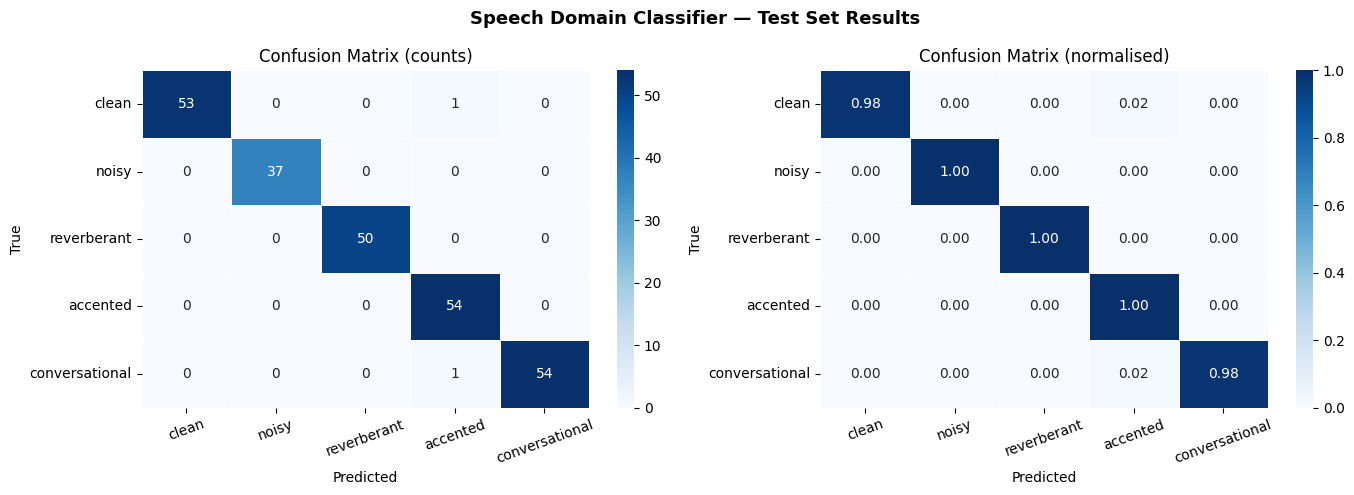

✓ Saved confusion_matrix.png


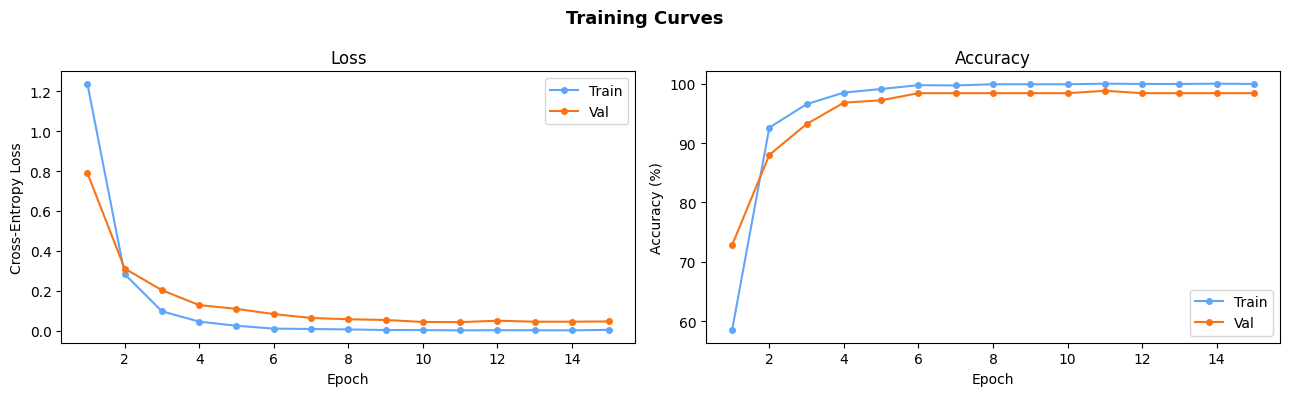

✓ Saved training_curves.png


In [13]:
# Cell 13 - Confusion matrix and training curves
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np
import os

os.makedirs("results", exist_ok=True)
domain_names = ["clean", "noisy", "reverberant", "accented", "conversational"]

# ── Confusion matrix ──────────────────────────────────────────
cm      = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Speech Domain Classifier — Test Set Results", fontsize=13, fontweight="bold")

sns.heatmap(cm, annot=True, fmt="d", xticklabels=domain_names,
            yticklabels=domain_names, cmap="Blues", ax=axes[0],
            linewidths=0.5, linecolor="white")
axes[0].set_title("Confusion Matrix (counts)")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")
axes[0].tick_params(axis="x", rotation=20)

sns.heatmap(cm_norm, annot=True, fmt=".2f", xticklabels=domain_names,
            yticklabels=domain_names, cmap="Blues", ax=axes[1],
            linewidths=0.5, linecolor="white", vmin=0, vmax=1)
axes[1].set_title("Confusion Matrix (normalised)")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.savefig("results/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved confusion_matrix.png")

# ── Training curves ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Training Curves", fontsize=13, fontweight="bold")
epochs_range = range(1, EPOCHS + 1)

axes[0].plot(epochs_range, history["train_loss"], "o-", color="#60a5fa", label="Train", markersize=4)
axes[0].plot(epochs_range, history["val_loss"],   "o-", color="#f97316", label="Val",   markersize=4)
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-Entropy Loss")
axes[0].legend()

axes[1].plot(epochs_range, [a*100 for a in history["train_acc"]], "o-", color="#60a5fa", label="Train", markersize=4)
axes[1].plot(epochs_range, [a*100 for a in history["val_acc"]],   "o-", color="#f97316", label="Val",   markersize=4)
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].legend()

plt.tight_layout()
plt.savefig("results/training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved training_curves.png")

In [14]:
# Cell 14 - Layer-wise probing
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

print("Running layer-wise probing experiments...")
print("Extracting representations from all 13 layers...\n")

@torch.no_grad()
def extract_layer_reps(loader, layer_idx):
    model.eval()
    all_reps, all_labels = [], []
    for batch in loader:
        input_values = batch["input_values"].to(DEVICE)
        with torch.amp.autocast('cuda'):
            out = model(input_values)
        hidden = out["hidden_states"][layer_idx]
        pooled = hidden.mean(dim=1)
        all_reps.append(pooled.cpu().numpy())
        all_labels.append(batch["labels"].numpy())
    return np.vstack(all_reps), np.concatenate(all_labels)

probe_results = []

for layer_idx in range(13):
    X_train, y_train = extract_layer_reps(train_loader, layer_idx)
    X_val,   y_val   = extract_layer_reps(val_loader,   layer_idx)

    scaler    = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_val_s   = scaler.transform(X_val)

    probe = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")
    probe.fit(X_train_s, y_train)

    val_acc = probe.score(X_val_s, y_val)
    val_f1  = f1_score(y_val, probe.predict(X_val_s), average="macro")

    probe_results.append({
        "layer":        layer_idx,
        "val_accuracy": val_acc,
        "val_macro_f1": val_f1
    })
    print(f"  Layer {layer_idx:>2} | Acc: {val_acc:.4%} | Macro F1: {val_f1:.4f}")

best_layer = max(probe_results, key=lambda x: x["val_accuracy"])
print(f"\n✓ Best probing layer: {best_layer['layer']} with {best_layer['val_accuracy']:.4%} accuracy")

Running layer-wise probing experiments...
Extracting representations from all 13 layers...

  Layer  0 | Acc: 100.0000% | Macro F1: 1.0000
  Layer  1 | Acc: 99.6000% | Macro F1: 0.9966
  Layer  2 | Acc: 99.2000% | Macro F1: 0.9931
  Layer  3 | Acc: 98.4000% | Macro F1: 0.9850
  Layer  4 | Acc: 99.2000% | Macro F1: 0.9931
  Layer  5 | Acc: 98.8000% | Macro F1: 0.9890
  Layer  6 | Acc: 99.2000% | Macro F1: 0.9931
  Layer  7 | Acc: 98.8000% | Macro F1: 0.9885
  Layer  8 | Acc: 99.2000% | Macro F1: 0.9925
  Layer  9 | Acc: 99.6000% | Macro F1: 0.9965
  Layer 10 | Acc: 99.6000% | Macro F1: 0.9965
  Layer 11 | Acc: 100.0000% | Macro F1: 1.0000
  Layer 12 | Acc: 100.0000% | Macro F1: 1.0000

✓ Best probing layer: 0 with 100.0000% accuracy


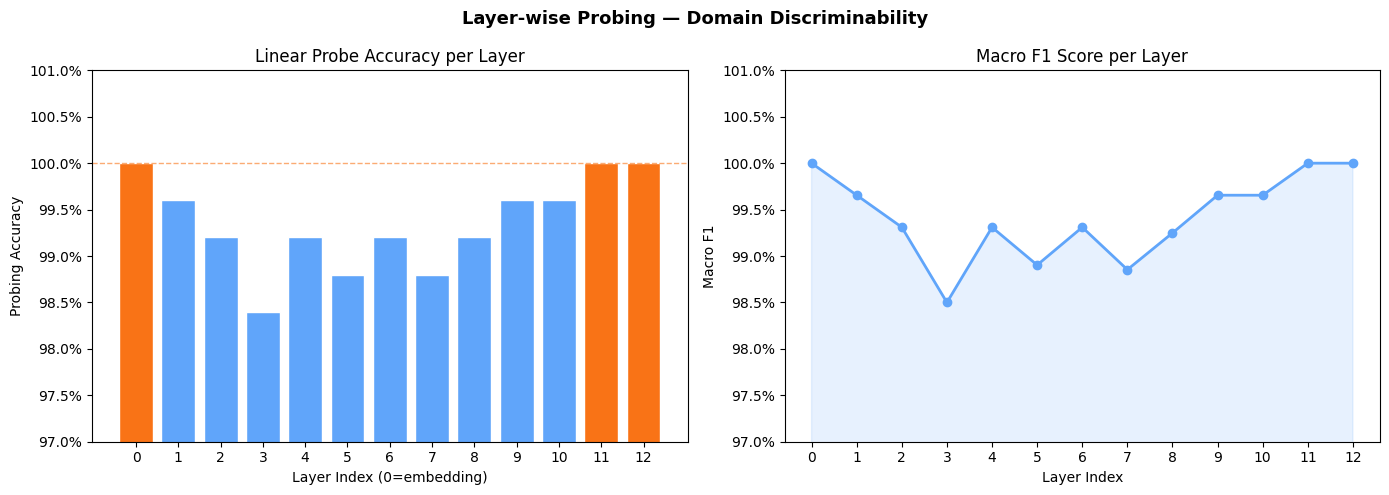

✓ Saved layer_probing.png


In [15]:
# Cell 15 - Probing visualisations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Layer-wise Probing — Domain Discriminability", fontsize=13, fontweight="bold")

layers   = [r["layer"] for r in probe_results]
accs     = [r["val_accuracy"] for r in probe_results]
f1s      = [r["val_macro_f1"] for r in probe_results]
colors   = ["#f97316" if a == 1.0 else "#60a5fa" for a in accs]

axes[0].bar(layers, accs, color=colors, edgecolor="white")
axes[0].axhline(1.0, color="#f97316", linestyle="--", linewidth=1, alpha=0.6)
axes[0].set_xlabel("Layer Index (0=embedding)")
axes[0].set_ylabel("Probing Accuracy")
axes[0].set_title("Linear Probe Accuracy per Layer")
axes[0].set_xticks(layers)
axes[0].set_ylim(0.97, 1.01)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.1%}"))

axes[1].plot(layers, f1s, "o-", color="#60a5fa", linewidth=2, markersize=6)
axes[1].fill_between(layers, f1s, alpha=0.15, color="#60a5fa")
axes[1].set_xlabel("Layer Index")
axes[1].set_ylabel("Macro F1")
axes[1].set_title("Macro F1 Score per Layer")
axes[1].set_xticks(layers)
axes[1].set_ylim(0.97, 1.01)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.1%}"))

plt.tight_layout()
plt.savefig("results/layer_probing.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved layer_probing.png")

Generating t-SNE for layer 0...


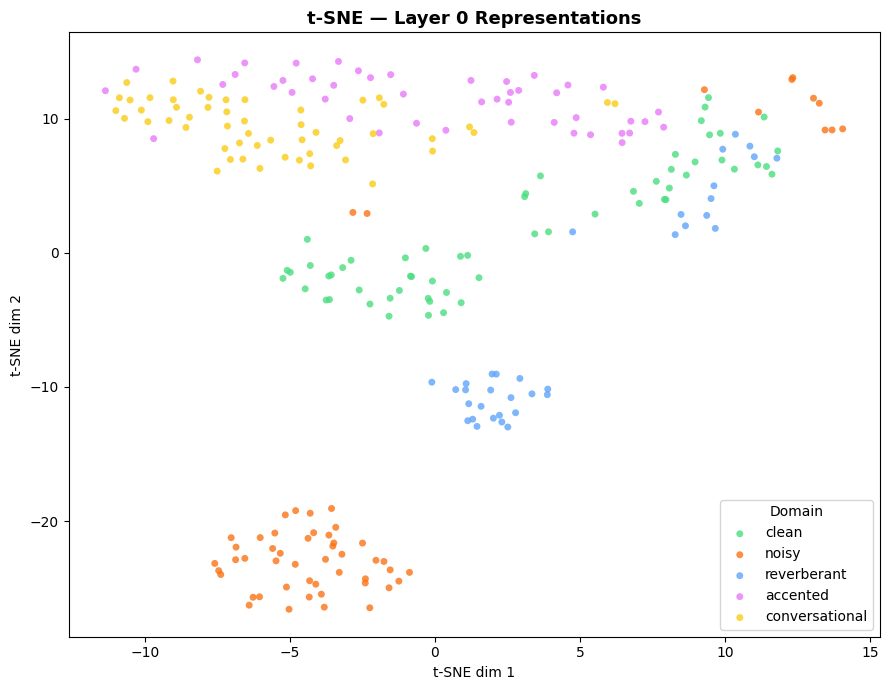

✓ Saved tsne.png


In [16]:
# Cell 16 - t-SNE of best layer (layer 0)
print("Generating t-SNE for layer 0...")

X_all, y_all = extract_layer_reps(val_loader, 0)
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_all)

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_2d = tsne.fit_transform(X_scaled)

COLORS       = ["#4ade80", "#f97316", "#60a5fa", "#e879f9", "#facc15"]
domain_names = ["clean", "noisy", "reverberant", "accented", "conversational"]

fig, ax = plt.subplots(figsize=(9, 7))
for i, (domain, color) in enumerate(zip(domain_names, COLORS)):
    mask = y_all == i
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1], c=color,
               label=domain, alpha=0.8, s=25, edgecolors="none")

ax.legend(title="Domain", fontsize=10)
ax.set_title("t-SNE — Layer 0 Representations", fontsize=13, fontweight="bold")
ax.set_xlabel("t-SNE dim 1")
ax.set_ylabel("t-SNE dim 2")
plt.tight_layout()
plt.savefig("results/tsne.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved tsne.png")